# Bayes Ingenuo (Gaussiano) : (Gaussian) Naive Bayes

Pamela Cerdas 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from collections import Counter 

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score  
from sklearn.metrics import confusion_matrix

from sklearn.naive_bayes import GaussianNB

In [6]:
data = pd.read_csv(
    "pima-indians-diabetes.csv",
    header=None
)

data.columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
data.shape

(768, 9)

In [5]:
mypath = "pima-indians-diabetes.csv"

data = pd.read_csv(mypath, sep=",", header='infer')
data.head(3)

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0


In [8]:
X = data[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]
Y = data[['Outcome']]

In [9]:
Counter(Y['Outcome'])

Counter({0: 500, 1: 268})

In [10]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, Y, train_size=0.7, random_state=7)

print(Xtrain.shape)
print(Xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(537, 8)
(231, 8)
(537, 1)
(231, 1)


In [11]:
kfold = KFold(n_splits=10, random_state=7, shuffle=True)
modeloGNB = GaussianNB()
sol = cross_val_score(modeloGNB, Xtrain, np.ravel(ytrain), cv=kfold)
print(sol.mean())

0.7614954577218728


Segun el modelo, de cada 100 pacientes acierta 76% y se equivoca con el 24%, esto ya siendo 768 pacientes, 500 si diabetes y 268 con diabetes 

In [12]:
modeloGNB.fit(Xtrain, np.ravel(ytrain))
yhat = modeloGNB.predict(Xtest)

cm = confusion_matrix(ytest, np.ravel(yhat))    # los renglones son los reales y las columnas las predicciones.
print(cm)

[[116  31]
 [ 29  55]]


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import RocCurveDisplay

In [14]:
modelokNN = KNeighborsClassifier().fit(Xtrain, np.ravel(ytrain))
modelokNN.score(Xtest,ytest)

0.6883116883116883

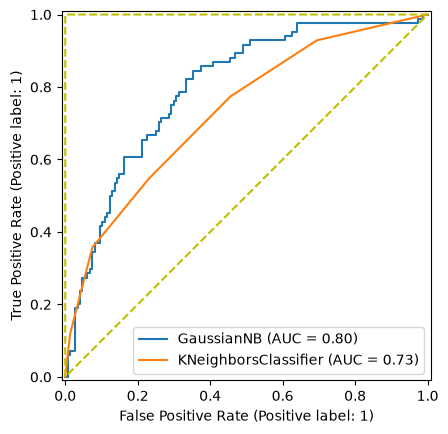

In [15]:
gnb_curve = RocCurveDisplay.from_estimator(modeloGNB, Xtest, ytest)
knn_curve = RocCurveDisplay.from_estimator(modelokNN, Xtest, ytest, ax=gnb_curve.ax_)

plt.plot([0,0,1,0],[0,1,1,0], 'y--')
plt.show() 

Como interpreta el desempeño de ambos modelos la curva de Roc? 
Bueno segun la grafica de la curva de Roc, el modelo que presentó mejor modelo es el GaussianNB con 80%, en cambio el KNN un 73%. Teniendo mejor precision GaussianNB